In [232]:
import torch
import torch.nn as nn

In [233]:
x = torch.arange(1 , 10)
x = x.reshape(1 , 3 , 3)
# print(y , y.shape , y.ndim)
print(x , x.shape , x.ndim)

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]]) torch.Size([1, 3, 3]) 3


In [234]:
x[: , : , 1]

tensor([[2, 5, 8]])

In [235]:
import numpy as np


In [236]:
array = np.arange(1.0 , 8.0)
tensor = torch.from_numpy(array)
array , tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [237]:
array = array+1
array , tensor # changing in numpy array do not change converted tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [238]:
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor , numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [239]:
import random
torch.manual_seed(42)
random_tensor_A = torch.rand(3,4)

torch.random.manual_seed(seed = 42)
random_tensor_B = torch.rand(3 , 4)
print(random_tensor_A , random_tensor_B )
random_tensor_A == random_tensor_B

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]]) tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

In [240]:
torch.cuda.is_available()

True

In [241]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.device_count() , device


(1, 'cuda')

In [242]:
tensor  = torch.tensor([1 , 2 , 3])
tensor.to(device)

tensor([1, 2, 3], device='cuda:0')

In [243]:
tensor_back = tensor.numpy()
tensor_back

array([1, 2, 3])

In [244]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

# ***Building a Model***

In [245]:
train_split = int(0.8 * len(X))
X_train , y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [246]:
import matplotlib.pyplot as plt

In [247]:
def plot_predictions(train_data = X_train , train_labels = y_train , test_data = X_test , test_labels = y_test , predictions = None):
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
      # Plot the predictions in red (predictions were made on the test data)
      plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14});

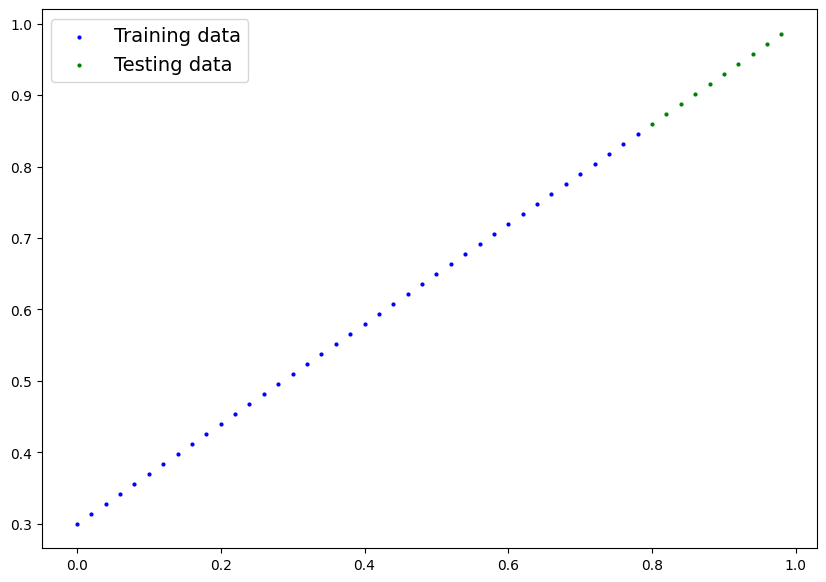

In [248]:
plot_predictions()

In [249]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn( 1 , dtype = torch.float), requires_grad = True)
    self.bias = nn.Parameter(torch.randn( 1 , dtype = torch.float32) , requires_grad = True)

  def forward(self , x : torch.Tensor) -> torch.Tensor:
    return self.weights*x + self.bias


In [250]:
torch.manual_seed(42)
model_0 = LinearRegression()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [251]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [252]:
with torch.inference_mode():
  y_preds = model_0(X_test)


In [253]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


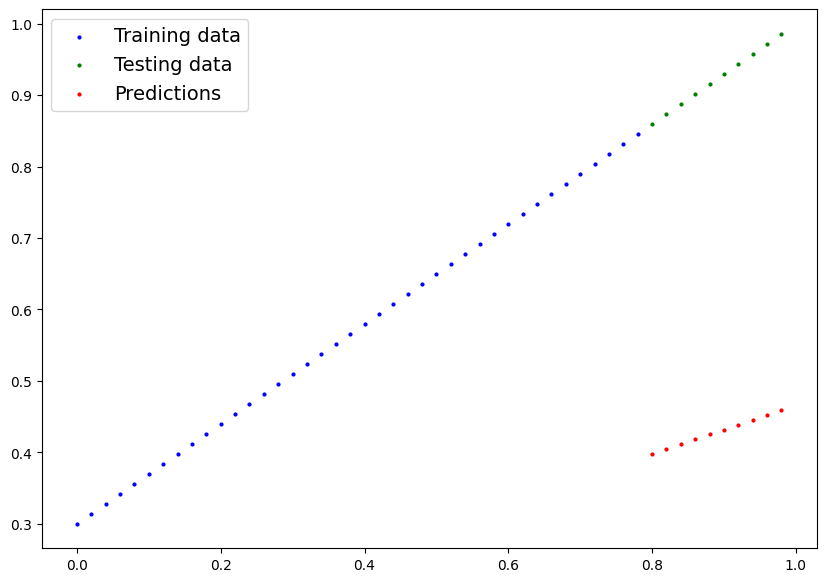

In [254]:
plot_predictions(predictions = y_preds)

In [255]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [256]:
loss_fn = nn.L1Loss() #MAE loss

optimizer = torch.optim.SGD(params = model_0.parameters() , lr = 0.01)

# **Neural Network Classification**

In [257]:
from sklearn.datasets import make_circles

n_samples = 1000

X , y = make_circles( n_samples , noise = 0.03 , random_state = 42 )


In [258]:
help(make_circles)

Help on function make_circles in module sklearn.datasets._samples_generator:

make_circles(
    n_samples=100,
    *,
    shuffle=True,
    noise=None,
    random_state=None,
    factor=0.8
)
    Make a large circle containing a smaller circle in 2d.

    A simple toy dataset to visualize clustering and classification
    algorithms.

    Read more in the :ref:`User Guide <sample_generators>`.

    Parameters
    ----------
    n_samples : int or tuple of shape (2,), dtype=int, default=100
        If int, it is the total number of points generated.
        For odd numbers, the inner circle will have one point more than the
        outer circle.
        If two-element tuple, number of points in outer circle and inner
        circle.

        .. versionchanged:: 0.23
           Added two-element tuple.

    shuffle : bool, default=True
        Whether to shuffle the samples.

    noise : float, default=None
        Standard deviation of Gaussian noise added to the data.

    random_state

In [259]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [260]:
X.shape , y.shape , type(X) , type(y)

(torch.Size([1000, 2]), torch.Size([1000]), torch.Tensor, torch.Tensor)

In [261]:
X[:10] , y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967],
         [-0.4796,  0.6764],
         [-0.0136,  0.8033],
         [ 0.7715,  0.1478],
         [-0.1693, -0.7935],
         [-0.1215,  1.0215]]),
 tensor([1., 1., 1., 1., 0.]))

In [262]:
import pandas as pd
circles = pd.DataFrame({"X1" : X[: , 0] ,
                        "X2": X[: , 1] , "Label" : y})
circles.head(10)

,X1,X2,Label
0,0.754246,0.231481,1.0
1,-0.756159,0.153259,1.0
2,-0.815392,0.173282,1.0
3,-0.393731,0.692883,1.0
4,0.442208,-0.896723,0.0
5,-0.479646,0.676435,1.0
6,-0.013648,0.803349,1.0
7,0.771513,0.147760,1.0
8,-0.169322,-0.793456,1.0
9,-0.121486,1.021509,0.0


In [263]:
circles.Label.value_counts()

,count
Label,
1.0,500
0.0,500


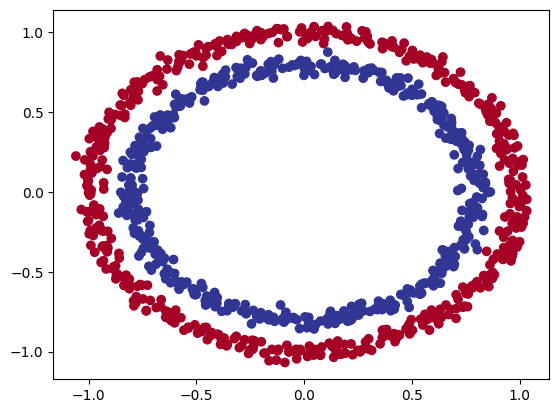

In [264]:
import matplotlib.pyplot as plt
plt.scatter(x = X[: , 0] , y = X[: , 1] ,c = y , cmap = plt.cm.RdYlBu)

In [265]:
help(plt.scatter)

Help on function scatter in module matplotlib.pyplot:

scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    *,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    colorizer: 'Colorizer | None' = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs
) -> 'PathCollection'
    A scatter plot of *y* vs. *x* with varying marker size and/or color.

    Parameters
    ----------
    x, y : float or array-like, shape (n, )
        The data positions.

    s : float or array-like, shape (n, ), optional
        The marker size in points**

In [266]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state= 42)

# **2 ways to create e Network**
Using:
1.   nn.Module Class
2.   nn.sequential()



# Using nn.Module

In [267]:
class Model_p(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2 , out_features= 10 )
    self.layer_2 = nn.Linear(in_features = 10 , out_features = 10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self , x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))



Model_p = Model_p().to(device)
Model_p

Model_p(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

# Using nn.sequential()

In [268]:
# Model_p = nn.Sequential(
#     nn.Linear(in_features = 2 , out_features = 5),
#     nn.Linear(in_features = 5 , out_features = 1)
# ).to(device)

# Model_p

In [269]:
untrained_preds = Model_p(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.2311],
        [0.2336],
        [0.2923],
        [0.2215],
        [0.2847],
        [0.2883],
        [0.2407],
        [0.2555],
        [0.2914],
        [0.2312]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [270]:
loss_fn = nn.BCEWithLogitsLoss() #it has a sigmoid smoothy built in
optimizer = torch.optim.SGD(params = Model_p.parameters() , lr = 0.1)

In [271]:
def accuracy_fn(y_true , y_pred):
  correct = torch.eq(y_true , y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [272]:
y_logits = Model_p(X_test.to(device))[:5]
y_logits

tensor([[0.2311],
        [0.2336],
        [0.2923],
        [0.2215],
        [0.2847]], device='cuda:0', grad_fn=<SliceBackward0>)

In [273]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5575],
        [0.5581],
        [0.5725],
        [0.5551],
        [0.5707]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [274]:
y_preds = torch.round(y_pred_probs)
y_pred_labels = torch.round(torch.sigmoid(Model_p(X_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze() , y_pred_labels.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [275]:
torch.manual_seed(42)
epochs = 1000

X_train , y_train = X_train.to(device) , y_train.to(device)
X_test , y_test = X_test.to(device) , y_test.to(device)

for epoch in range(epochs):
  Model_p.train()
  y_logits = Model_p(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
  acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
  optimizer.zero_grad()

    # 4. Loss backwards
  loss.backward()

    # 5. Optimizer step
  optimizer.step()
  Model_p.eval()
  with torch.inference_mode():
    test_logits = Model_p(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits , y_test)
    test_acc = accuracy_fn (y_true = y_test , y_pred = test_pred)

  if epoch %10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.70172, Accuracy: 50.00% | Test loss: 0.69970, Test acc: 50.00%
Epoch: 10 | Loss: 0.69730, Accuracy: 50.00% | Test loss: 0.69560, Test acc: 50.00%
Epoch: 20 | Loss: 0.69481, Accuracy: 50.00% | Test loss: 0.69332, Test acc: 50.00%
Epoch: 30 | Loss: 0.69331, Accuracy: 50.00% | Test loss: 0.69194, Test acc: 50.00%
Epoch: 40 | Loss: 0.69235, Accuracy: 50.00% | Test loss: 0.69105, Test acc: 50.00%
Epoch: 50 | Loss: 0.69162, Accuracy: 50.00% | Test loss: 0.69039, Test acc: 50.00%
Epoch: 60 | Loss: 0.69105, Accuracy: 56.38% | Test loss: 0.68990, Test acc: 58.50%
Epoch: 70 | Loss: 0.69066, Accuracy: 62.50% | Test loss: 0.68952, Test acc: 65.50%
Epoch: 80 | Loss: 0.69036, Accuracy: 59.00% | Test loss: 0.68921, Test acc: 60.00%
Epoch: 90 | Loss: 0.69011, Accuracy: 62.50% | Test loss: 0.68892, Test acc: 61.00%
Epoch: 100 | Loss: 0.68987, Accuracy: 62.88% | Test loss: 0.68863, Test acc: 64.00%
Epoch: 110 | Loss: 0.68964, Accuracy: 61.00% | Test loss: 0.68835, Test acc: 63.50%
Epo

In [276]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


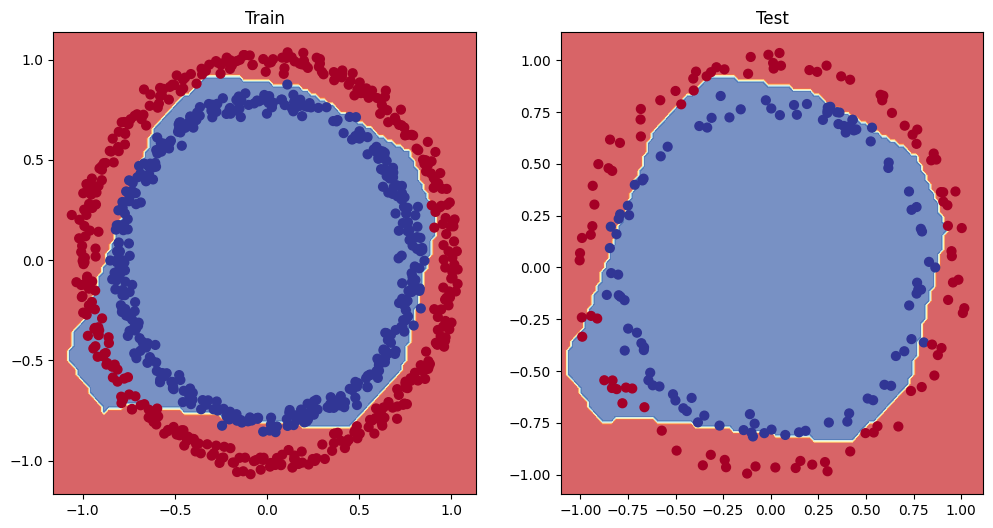

In [277]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_p, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_p, X_test, y_test)